# Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
import scipy as sc
from matplotlib import pyplot
from numpy import mean, std
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad
import time
import astropy.cosmology as ac
import astropy.constants as cst
from scipy.misc import derivative
import csv
from sklearn.linear_model import LinearRegression
import statistics as stat
from astropy.io import fits

c:\Users\cleam\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\cleam\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
#graph parameters
police=15

Fiducial cosmologies

In [3]:
# define cosmological parameters
H0=73
Mb=-19.3
c=float(np.array(cst.c.to('km/s')))


#for flat LCDM, according to Planck 2018 (TT,TE,EE+lowE+lensing)
Om0_fLCDM = 0.3153
Ode0_fLCDM = 1-Om0_fLCDM

#for LCDM
Om0_kLCDM, Ode0_kLCDM = 0.3153, 0.6
Ok0_kLCDM = 1-Om0_kLCDM-Ode0_kLCDM

#for flat wCDM
Om0_fwCDM, w0_fwCDM = 0.3153, -1.029

#for k-wCDM
Om0_kwCDM, Ode0_kwCDM, w0_kwCDM =  0.3153, 0.6, -1.029

#for flat CPL
Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21

#for CPL
Om0_kCPL, Ode0_kCPL, w0_kCPL, wa_kCPL = 0.3153, 0.6, -1.029, 0.21

#for PEDE
Om0_PEDE, Ode0_PEDE = 0.3153, 0.6
Ok0_PEDE=1-Om0_PEDE-Ode0_PEDE


In [4]:
# astropy cosmo

#LCDM
cosmo_fLCDM = ac.FlatLambdaCDM(H0=H0,Om0=Om0_fLCDM)
cosmo_kLCDM = ac.LambdaCDM(H0=H0,Om0=Om0_kLCDM,Ode0=Ode0_kLCDM)

#wCDM
cosmo_fwCDM = ac.FlatwCDM(H0=H0,Om0=Om0_fwCDM,w0=w0_fwCDM)
cosmo_kwCDM = ac.wCDM(H0=H0,Om0=Om0_kwCDM,Ode0=Ode0_kwCDM,w0=w0_kwCDM)

#CPL
cosmo_fCPL= ac.Flatw0waCDM(H0=H0, Om0=Om0_fCPL, w0=w0_fCPL, wa=wa_fCPL)
cosmo_kCPL= ac.w0waCDM(H0=H0, Om0=Om0_kCPL, Ode0=Ode0_kCPL, w0=w0_kCPL, wa=wa_kCPL)

# Roman data distribution

In [5]:
# Roman data

roman = pd.read_csv('mock_roman.csv', sep=';')
z_roman = roman.z.values
dist_roman = roman.Nstar.values

cov = fits.getdata("roman_cov.fits")

# first row = bin centers
C_roman = cov[0:-1, :]  

Cinv_roman = np.linalg.inv(C_roman)
sigma_roman = np.sqrt(np.diag(C_roman))

# define bin edges
edges_mid = 0.5 * (z_roman[1:] + z_roman[:-1])
# first and last edges
first_edge = z_roman[0] - (edges_mid[0] - z_roman[0])
last_edge  = z_roman[-1] + (z_roman[-1] - edges_mid[-1])

# combine
z_edges = np.concatenate([[first_edge], edges_mid, [last_edge]])

Text(0, 0.5, '# SNIa')

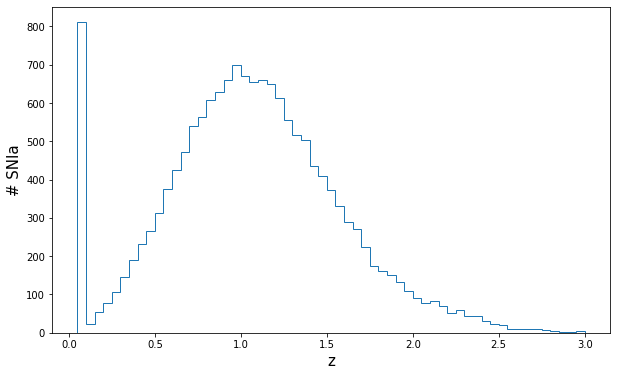

In [6]:
plt.figure(figsize=(10,6))
plt.stairs(dist_roman,z_edges)
plt.xlabel('z',fontsize=police)
plt.ylabel('# SNIa',fontsize=police)

# Roman mock data

In [7]:
#errors
# def sigma_tot_binned(distribution, z_bins):
    
#     # photometric measurement errors per SN
#     sigma_meas = np.zeros(len(z_bins))
#     sigma_meas.fill(0.08)
    
#     # intrinsic dispersion in SNIa luminosities
#     sigma_int = np.zeros(len(z_bins))
#     sigma_int.fill(0.09)

#     #gravitational lensing magnification
#     sigma_lens = 0.07*z_bins

#     #overall statistic error
#     sigma_stat = np.sqrt((sigma_meas**2+sigma_int**2+sigma_lens**2))/np.sqrt(distribution)


#     #systematic error per bin
#     sigma_sys = (0.01*(1+z_bins)/1.80)

#     #total error per bin
#     sigma_tot = np.sqrt(sigma_stat**2+sigma_sys**2)
        
#     return sigma_tot

In [8]:
# gaussian noise
np.random.seed(42)
noise_roman = np.random.multivariate_normal(
    mean=np.zeros(len(z_roman)),
    cov=C_roman
)


C:\Users\cleam\AppData\Local\Temp\ipykernel_55364\1144779142.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise_roman = np.random.multivariate_normal(


In [9]:
# PEDE cosmology
def omega_DE_tilde(z,Ode0):
    "takes a 1D-array of z and Omega_lambda0 in argument, return a 1D-array omega_lambda(z)"
    return Ode0*(1-np.tanh(np.log10(1+z)))

def integrand(z,Om0,Ode0):
    "takes a 1D-array of z and omega_m in argument, return a 1D-array of 1/H(z)"
    Ok0=1-Om0-Ode0
    return 1/np.sqrt(Om0*(1+z)**3+omega_DE_tilde(z,Ode0)+Ok0*(1+z)**2)

def mu_th(z,Om0,Ode0):
    "takes a 1D-array of z and omega_m in argument, return a 1D-array of mu(z)"
    I = quad(integrand, 0, z, (Om0,Ode0))[0]
    dl=I*c*(1+z)/H0
    return 5*np.log10(dl)+25

cosmo_PEDE=np.vectorize(mu_th)

In [10]:
#compute mb(z_roman) for the different cosmologies, add noise
mb_fLCDM=np.array(cosmo_fLCDM.distmod(z_roman)) + Mb + noise_roman
mb_kLCDM=np.array(cosmo_kLCDM.distmod(z_roman)) + Mb + noise_roman

mb_fwCDM=np.array(cosmo_fwCDM.distmod(z_roman)) + Mb + noise_roman
mb_kwCDM=np.array(cosmo_kwCDM.distmod(z_roman)) + Mb + noise_roman

mb_fCPL=np.array(cosmo_fCPL.distmod(z_roman)) + Mb + noise_roman
mb_kCPL=np.array(cosmo_kCPL.distmod(z_roman)) + Mb + noise_roman

mb_kPEDE=np.array(cosmo_PEDE(z_roman,Om0_PEDE,Ode0_PEDE)) + Mb + noise_roman

In [11]:
#save mock data
np.savez('NGR_fLCDM.npz',z=z_roman,mb=mb_fLCDM)
np.savez('NGR_kLCDM.npz',z=z_roman,mb=mb_kLCDM)

np.savez('NGR_fwCDM.npz',z=z_roman,mb=mb_fwCDM)
np.savez('NGR_kwCDM.npz',z=z_roman,mb=mb_kwCDM)

np.savez('NGR_fCPL.npz',z=z_roman,mb=mb_fCPL)
np.savez('NGR_kCPL.npz',z=z_roman,mb=mb_kCPL)

np.savez('NGR_kPEDE.npz',z=z_roman,mb=mb_kCPL)
